# Verlan Probe Results

This notebook is a lightweight viewer for the outputs produced by `scripts/run_verlan_probe.py`.

It focuses on four result types:

1. tokenization / subword fragmentation
2. layer-wise word similarity
3. layer-wise attention metrics
4. sentence-level drift and pair-specific case studies

If `outputs/verlan_probe/` does not exist yet, set `RUN_EXPERIMENT = True` in the next cell and run it once.

In [7]:
from pathlib import Path
import json
import subprocess

import matplotlib.pyplot as plt
import pandas as pd
from pandas.errors import EmptyDataError
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

ROOT = Path("..").resolve()
OUTPUT_DIR = ROOT / "outputs" / "verlan_probe"
RESULTS_CSV = OUTPUT_DIR / "experiment_results.csv"
TOKENIZATION_CSV = OUTPUT_DIR / "tokenization_results.csv"
FAILURES_CSV = OUTPUT_DIR / "failures.csv"
METADATA_JSON = OUTPUT_DIR / "run_metadata.json"
FIGURE_DIR = OUTPUT_DIR / "figures_from_notebook"

RUN_EXPERIMENT = False
MODEL_NAME = "camembert-base"
SAVE_FIGURES = True

if RUN_EXPERIMENT and not RESULTS_CSV.exists():
    cmd = ["python", "scripts/run_verlan_probe.py", "--model-name", MODEL_NAME]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Output dir:", OUTPUT_DIR)
print("Figure dir:", FIGURE_DIR)


Project root: /home/wan/github_project/llm_verlan/llm_verlan
Output dir: /home/wan/github_project/llm_verlan/llm_verlan/outputs/verlan_probe
Figure dir: /home/wan/github_project/llm_verlan/llm_verlan/outputs/verlan_probe/figures_from_notebook


In [8]:
required_files = [RESULTS_CSV, TOKENIZATION_CSV]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing probe outputs:\n- " + "\n- ".join(missing) + "\n\n"
        "Run `python scripts/run_verlan_probe.py --model-name camembert-base` from the repo root first, "
        "or set RUN_EXPERIMENT = True in the previous cell."
    )

def read_optional_csv(path):
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame()

results_df = pd.read_csv(RESULTS_CSV)
tokenization_df = pd.read_csv(TOKENIZATION_CSV)
failures_df = read_optional_csv(FAILURES_CSV)
metadata = json.loads(METADATA_JSON.read_text(encoding="utf-8")) if METADATA_JSON.exists() else {}

display(Markdown("## Run Metadata"))
display(pd.DataFrame([metadata]) if metadata else pd.DataFrame([{ "status": "missing run_metadata.json" }]))

print("results shape      :", results_df.shape)
print("tokenization shape :", tokenization_df.shape)
print("failures shape     :", failures_df.shape)


## Run Metadata

,model_name,device,pairs_csv,templates_csv,num_pairs,num_templates,num_sentence_jobs,num_completed_jobs,num_failed_jobs,attention_available_for_all_jobs
0,camembert-base,cuda,data/processed/verlan_probe_pairs.csv,data/processed/verlan_probe_templates.csv,5,12,15,15,0,True


results shape      : (195, 26)
tokenization shape : (30, 15)
failures shape     : (0, 0)


## 1. Tokenization / Subword Fragmentation

This table shows the average number of target subwords for each verlan-standard pair.

In [9]:
subword_summary = (
    tokenization_df.groupby(["verlan", "standard", "variant"])["num_target_subwords"]
    .mean()
    .reset_index()
    .pivot(index=["verlan", "standard"], columns="variant", values="num_target_subwords")
    .rename_axis(None, axis=1)
    .rename(columns={"verlan": "verlan_subwords", "standard": "standard_subwords"})
    .reset_index()
)
subword_summary["delta_verlan_minus_standard"] = (
    subword_summary["verlan_subwords"] - subword_summary["standard_subwords"]
)
subword_summary = subword_summary.sort_values(
    ["delta_verlan_minus_standard", "verlan_subwords"],
    ascending=[False, False],
)
display(subword_summary)


,verlan,standard,standard_subwords,verlan_subwords,delta_verlan_minus_standard
0,meufs,femmes,1.0,3.0,2.0
3,vénère,énervé,1.0,3.0,2.0
1,ouf,fou,1.0,2.0,1.0
2,teuf,fête,1.0,2.0,1.0
4,zarbi,bizarre,1.0,2.0,1.0


In [10]:
token_examples = tokenization_df[[
    "verlan",
    "standard",
    "variant",
    "sentence",
    "target_word",
    "target_tokens",
    "token_span_start",
    "token_span_end",
]].copy()
display(token_examples.head(12))


,verlan,standard,variant,sentence,target_word,target_tokens,token_span_start,token_span_end
0,meufs,femmes,verlan,Les meufs sont très joyeuses.,meufs,"[""▁me"", ""uf"", ""s""]",2,5
1,meufs,femmes,standard,Les femmes sont très joyeuses.,femmes,"[""▁femmes""]",2,3
2,meufs,femmes,verlan,Je parle avec ces meufs.,meufs,"[""▁me"", ""uf"", ""s""]",5,8
3,meufs,femmes,standard,Je parle avec ces femmes.,femmes,"[""▁femmes""]",5,6
4,meufs,femmes,verlan,On voit les meufs dans la rue.,meufs,"[""▁me"", ""uf"", ""s""]",4,7
5,meufs,femmes,standard,On voit les femmes dans la rue.,femmes,"[""▁femmes""]",4,5
6,teuf,fête,verlan,La teuf commence bientôt.,teuf,"[""▁te"", ""uf""]",2,4
7,teuf,fête,standard,La fête commence bientôt.,fête,"[""▁fête""]",2,3
8,teuf,fête,verlan,On parle souvent de cette teuf.,teuf,"[""▁te"", ""uf""]",6,8
9,teuf,fête,standard,On parle souvent de cette fête.,fête,"[""▁fête""]",6,7


## 2. Layer-wise Similarity

The first plot is word-level similarity for the substituted target word.
The second plot is sentence-level similarity after replacing the verlan form with the standard form.

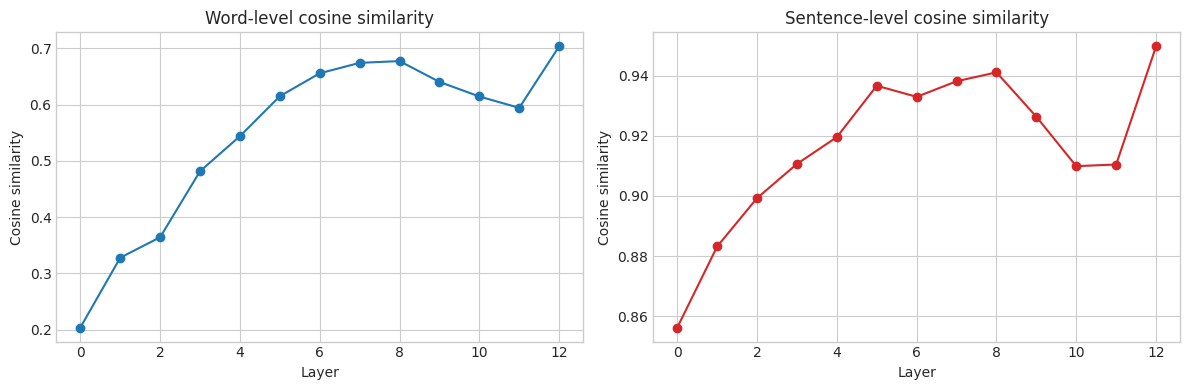

,layer,word_similarity,sentence_similarity
0,0,0.203549,0.856261
1,1,0.327730,0.883204
2,2,0.364146,0.899280
3,3,0.481494,0.910632
4,4,0.543845,0.919552
5,5,0.614879,0.936620
6,6,0.655649,0.932919
7,7,0.674214,0.938094
8,8,0.677366,0.941064
9,9,0.640336,0.926307


In [11]:
layer_summary = results_df.groupby("layer", as_index=False)[["word_similarity", "sentence_similarity"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(layer_summary["layer"], layer_summary["word_similarity"], marker="o", color="#1f77b4")
axes[0].set_title("Word-level cosine similarity")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Cosine similarity")

axes[1].plot(layer_summary["layer"], layer_summary["sentence_similarity"], marker="o", color="#d62728")
axes[1].set_title("Sentence-level cosine similarity")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Cosine similarity")

plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR / "word_sentence_similarity.png", dpi=200, bbox_inches="tight")
plt.show()

display(layer_summary)


## 3. Layer-wise Attention Metrics

These plots average attention metrics across all sentence pairs.
`layer = 0` is excluded here because attention starts at the first transformer layer.

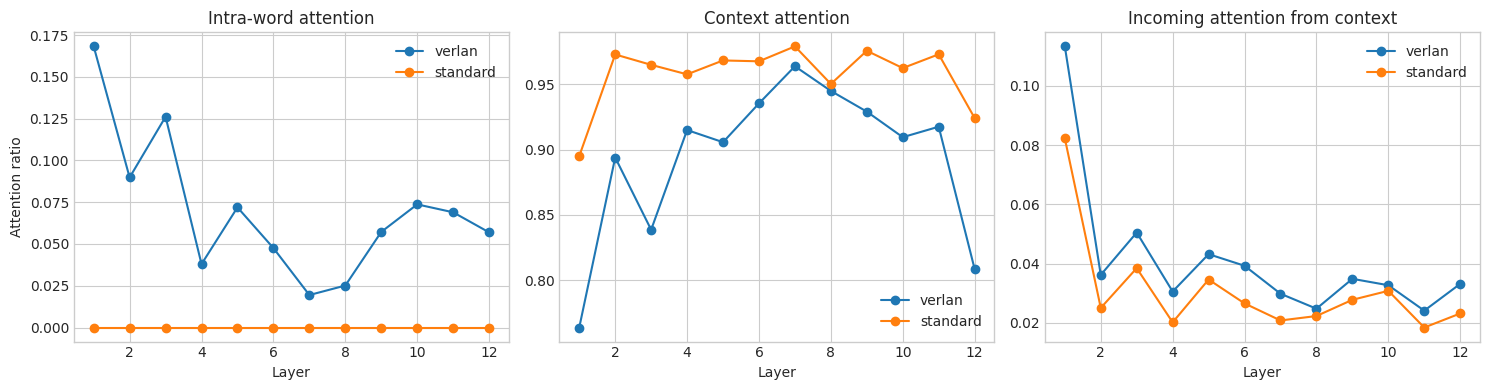

,layer,intra_verlan,intra_standard,context_verlan,context_standard,incoming_verlan,incoming_standard
0,1,0.168209,0.0,0.763728,0.894951,0.113281,0.082285
1,2,0.089787,0.0,0.893880,0.972756,0.036221,0.025076
2,3,0.126118,0.0,0.838576,0.964812,0.050503,0.038495
3,4,0.037950,0.0,0.914899,0.957535,0.030613,0.020223
4,5,0.071892,0.0,0.905586,0.968172,0.043211,0.034658
5,6,0.047534,0.0,0.935300,0.967510,0.039299,0.026604
6,7,0.019439,0.0,0.963701,0.978934,0.029868,0.020851
7,8,0.025122,0.0,0.944833,0.950168,0.024824,0.022350
8,9,0.057207,0.0,0.928981,0.975565,0.034893,0.027822
9,10,0.073681,0.0,0.909430,0.962321,0.032734,0.030847


In [12]:
attention_cols = [
    "intra_verlan",
    "intra_standard",
    "context_verlan",
    "context_standard",
    "incoming_verlan",
    "incoming_standard",
]
has_attention = results_df[attention_cols].notna().any().any()

if not has_attention:
    print("Attention weights were not available in this run. Hidden-state results are still usable.")
else:
    attn_summary = (
        results_df.loc[results_df["layer"] > 0]
        .groupby("layer", as_index=False)[attention_cols]
        .mean()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

    axes[0].plot(attn_summary["layer"], attn_summary["intra_verlan"], marker="o", label="verlan")
    axes[0].plot(attn_summary["layer"], attn_summary["intra_standard"], marker="o", label="standard")
    axes[0].set_title("Intra-word attention")
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Attention ratio")
    axes[0].legend()

    axes[1].plot(attn_summary["layer"], attn_summary["context_verlan"], marker="o", label="verlan")
    axes[1].plot(attn_summary["layer"], attn_summary["context_standard"], marker="o", label="standard")
    axes[1].set_title("Context attention")
    axes[1].set_xlabel("Layer")
    axes[1].legend()

    axes[2].plot(attn_summary["layer"], attn_summary["incoming_verlan"], marker="o", label="verlan")
    axes[2].plot(attn_summary["layer"], attn_summary["incoming_standard"], marker="o", label="standard")
    axes[2].set_title("Incoming attention from context")
    axes[2].set_xlabel("Layer")
    axes[2].legend()

    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / "attention_metrics.png", dpi=200, bbox_inches="tight")
    plt.show()

    display(attn_summary)


## 4. Pair Ranking at the Final Layer

This makes it easy to see which pairs align best or worst in the deepest representation.

In [13]:
final_layer = results_df["layer"].max()
final_layer_summary = (
    results_df.loc[results_df["layer"] == final_layer]
    .groupby(["verlan", "standard"], as_index=False)[["word_similarity", "sentence_similarity"]]
    .mean()
    .sort_values("word_similarity", ascending=False)
)
print("Final layer:", final_layer)
display(final_layer_summary)


Final layer: 12


,verlan,standard,word_similarity,sentence_similarity
2,teuf,fête,0.781034,0.944754
4,zarbi,bizarre,0.744032,0.963277
0,meufs,femmes,0.712478,0.952902
3,vénère,énervé,0.665566,0.926399
1,ouf,fou,0.614386,0.961100


## 5. Pair-specific Case Study

Set a pair here to inspect tokenization and layer-wise behavior in isolation.

In [14]:
CASE_VERLAN = "meufs"
CASE_STANDARD = "femmes"

pair_token_rows = tokenization_df[
    (tokenization_df["verlan"] == CASE_VERLAN) & (tokenization_df["standard"] == CASE_STANDARD)
].copy()
pair_result_rows = results_df[
    (results_df["verlan"] == CASE_VERLAN) & (results_df["standard"] == CASE_STANDARD)
].copy()

display(Markdown(f"### {CASE_VERLAN} vs {CASE_STANDARD}"))
display(pair_token_rows[[
    "variant",
    "template",
    "sentence",
    "target_word",
    "target_tokens",
    "token_span_start",
    "token_span_end",
]])


### meufs vs femmes

,variant,template,sentence,target_word,target_tokens,token_span_start,token_span_end
0,verlan,Les X sont très joyeuses.,Les meufs sont très joyeuses.,meufs,"[""▁me"", ""uf"", ""s""]",2,5
1,standard,Les X sont très joyeuses.,Les femmes sont très joyeuses.,femmes,"[""▁femmes""]",2,3
2,verlan,Je parle avec ces X.,Je parle avec ces meufs.,meufs,"[""▁me"", ""uf"", ""s""]",5,8
3,standard,Je parle avec ces X.,Je parle avec ces femmes.,femmes,"[""▁femmes""]",5,6
4,verlan,On voit les X dans la rue.,On voit les meufs dans la rue.,meufs,"[""▁me"", ""uf"", ""s""]",4,7
5,standard,On voit les X dans la rue.,On voit les femmes dans la rue.,femmes,"[""▁femmes""]",4,5


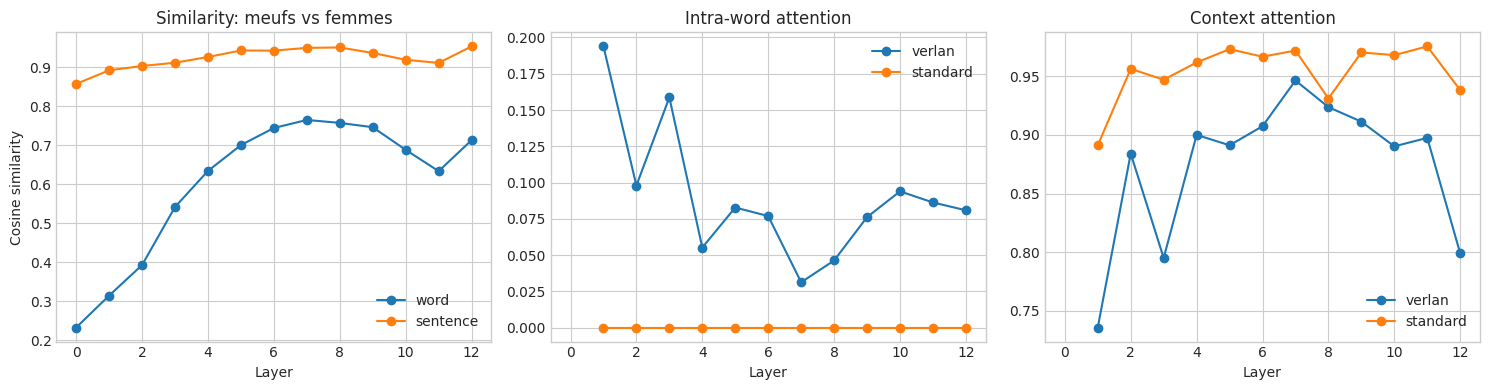

,layer,word_similarity,sentence_similarity,intra_verlan,intra_standard,context_verlan,context_standard
0,0,0.232069,0.856717,NaN,NaN,NaN,NaN
1,1,0.313982,0.891624,0.193864,0.0,0.735743,0.891221
2,2,0.392299,0.902650,0.097894,0.0,0.884102,0.956405
3,3,0.541207,0.911021,0.158655,0.0,0.795067,0.947101
4,4,0.633661,0.925779,0.055159,0.0,0.900085,0.961824
5,5,0.699841,0.942412,0.082740,0.0,0.891181,0.973204
6,6,0.743732,0.941971,0.076866,0.0,0.907449,0.966763
7,7,0.764293,0.949152,0.031215,0.0,0.946462,0.972004
8,8,0.756730,0.950145,0.046224,0.0,0.923727,0.931059
9,9,0.745645,0.936035,0.076133,0.0,0.911337,0.970382


In [15]:
pair_layer_summary = pair_result_rows.groupby("layer", as_index=False)[[
    "word_similarity",
    "sentence_similarity",
    "intra_verlan",
    "intra_standard",
    "context_verlan",
    "context_standard",
]].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

axes[0].plot(pair_layer_summary["layer"], pair_layer_summary["word_similarity"], marker="o", label="word")
axes[0].plot(pair_layer_summary["layer"], pair_layer_summary["sentence_similarity"], marker="o", label="sentence")
axes[0].set_title(f"Similarity: {CASE_VERLAN} vs {CASE_STANDARD}")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Cosine similarity")
axes[0].legend()

attn_pair = pair_layer_summary[pair_layer_summary["layer"] > 0]
if attn_pair[["intra_verlan", "intra_standard", "context_verlan", "context_standard"]].notna().any().any():
    axes[1].plot(attn_pair["layer"], attn_pair["intra_verlan"], marker="o", label="verlan")
    axes[1].plot(attn_pair["layer"], attn_pair["intra_standard"], marker="o", label="standard")
    axes[1].set_title("Intra-word attention")
    axes[1].set_xlabel("Layer")
    axes[1].legend()

    axes[2].plot(attn_pair["layer"], attn_pair["context_verlan"], marker="o", label="verlan")
    axes[2].plot(attn_pair["layer"], attn_pair["context_standard"], marker="o", label="standard")
    axes[2].set_title("Context attention")
    axes[2].set_xlabel("Layer")
    axes[2].legend()
else:
    axes[1].set_title("Intra-word attention unavailable")
    axes[2].set_title("Context attention unavailable")

plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR / f"{CASE_VERLAN}_{CASE_STANDARD}_case_study.png", dpi=200, bbox_inches="tight")
plt.show()

display(pair_layer_summary)


## 6. Failed Span Matches

If anything failed during the experiment, inspect it here first.

In [16]:
if failures_df.empty:
    print("No failures recorded.")
else:
    display(failures_df)


No failures recorded.
